In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import random
import json

# 1. Define file paths
train_dir = 'train_set'
val_dir = 'validation_set'
test_dir = 'test_set'

# Define global parameters
point_radius = 5  

# Crop images
def combine_data_and_images(image_R, image_T):
    left = 135
    upper = 13
    right = 740
    lower = 618
    # Use numpy slicing for cropping
    cropped_image_R = image_R[upper:lower, left:right]
    cropped_image_T = image_T[upper:lower, left:right]
    return cropped_image_R, cropped_image_T

# Get all data paths in the dataset
def get_data_paths(data_dir):
    data_paths = []
    for root, dirs, files in os.walk(data_dir):
        files_lower = [f.lower() for f in files]
        required_files = ['filtered_r_image.tif', 'filtered_t_image.tif', 'image_data.csv']
        if all(f in files_lower for f in required_files):
            data_paths.append(root)
    return data_paths

# Normalize and scale x and y coordinates to the range 0-605
def transform_coordinates(data):
    x_min, x_max = data['x'].min(), data['x'].max()
    y_min, y_max = data['y'].min(), data['y'].max()
    data['x_new'] = ((data['x'] - x_min) / (x_max - x_min)) * 605
    data['y_new'] = ((data['y'] - y_min) / (y_max - y_min)) * 605
    return data[['x_new', 'y_new']]

# Get training, validation, and test data paths
train_paths = get_data_paths(train_dir)
val_paths = get_data_paths(val_dir)
test_paths = get_data_paths(test_dir)

# Check if datasets are empty
if not train_paths:
    raise ValueError("No training data found. Please check the training data directory and file names.")
else:
    print(f"Found {len(train_paths)} training samples.")

if not val_paths:
    print("No validation data found. Please check the validation data directory and file names.")
else:
    print(f"Found {len(val_paths)} validation samples.")

if not test_paths:
    print("No test data found. Please check the test data directory and file names.")
else:
    print(f"Found {len(test_paths)} test samples.")

# Define image enhancement function
def enhance_contrast_and_brightness(img, contrast_factor=2.0, brightness_factor=2.5):
    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert to PIL image
    brightness_enhancer = ImageEnhance.Brightness(img_pil)
    brightened_img = brightness_enhancer.enhance(brightness_factor)
    contrast_enhancer = ImageEnhance.Contrast(brightened_img)
    enhanced_img = contrast_enhancer.enhance(contrast_factor)
    return cv2.cvtColor(np.array(enhanced_img), cv2.COLOR_RGB2BGR)  # Convert back to OpenCV format

# Define data generator for batch loading and preprocessing
class DataGenerator(Sequence):
    def __init__(self, list_IDs, batch_size=8, shuffle=True, augment=False):
        """
        Initialize the data generator.

        Arguments:
            list_IDs (list): List of subfolder paths for the data.
            batch_size (int): Number of samples per batch.
            shuffle (bool): Whether to shuffle the data after each epoch.
            augment (bool): Whether to apply data augmentation.
        """
        self.list_IDs = list_IDs
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indexes = np.arange(len(self.list_IDs))
        self.on_epoch_end()

    # Return the number of steps per epoch
    def __len__(self):
        return int(np.floor(len(self.list_IDs) / self.batch_size))
    
    # Generate one batch of data
    def __getitem__(self, index):
        # Generate indices for the current batch
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        # Get the current batch's IDs
        list_IDs_temp = [self.list_IDs[k] for k in indexes]
        # Generate data
        X, y = self.__data_generation(list_IDs_temp)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    # Generate batch data
    def __data_generation(self, list_IDs_temp):
        # Initialize
        X_batch = []
        y_batch = []
        for ID in list_IDs_temp:
            # Load and preprocess data
            X, y = load_and_preprocess_data(ID, self.augment)
            X_batch.append(X)
            y_batch.append(y)
        # Convert to arrays
        X_batch = np.array(X_batch)
        y_batch = np.array(y_batch)
        return X_batch, y_batch

# Load image and label data and preprocess
def load_and_preprocess_data(data_path, augment=False):
    image_path_R = os.path.join(data_path, 'Filtered_R_Image.tif')
    image_path_T = os.path.join(data_path, 'Filtered_T_Image.tif')
    csv_path = os.path.join(data_path, 'image_data.csv')

    # Load RGB images
    image_R = cv2.imread(image_path_R, cv2.IMREAD_COLOR)
    if image_R is None:
        raise ValueError(f"Cannot read image file: {image_path_R}")
    image_R = cv2.cvtColor(image_R, cv2.COLOR_BGR2RGB)

    image_T = cv2.imread(image_path_T, cv2.IMREAD_COLOR)
    if image_T is None:
        raise ValueError(f"Cannot read image file: {image_path_T}")
    image_T = cv2.cvtColor(image_T, cv2.COLOR_BGR2RGB)

    # Crop both images
    image_R, image_T = combine_data_and_images(image_R, image_T)

    # Apply image augmentation (if augment is True)
    if augment:
        # Randomize factors to increase diversity
        contrast = random.uniform(1.0, 2.0) 
        brightness = random.uniform(1.0, 2.5)  
        image_R = enhance_contrast_and_brightness(image_R, contrast, brightness)
        image_T = enhance_contrast_and_brightness(image_T, contrast, brightness)

    # Load the CSV file
    if not os.path.exists(csv_path):
        raise ValueError(f"File not found: {csv_path}")
    data = pd.read_csv(csv_path)

    # Apply coordinate transformation
    transformed = transform_coordinates(data)
    data[['x_new', 'y_new']] = transformed

    # Get image dimensions
    height, width, _ = image_R.shape

    # Extract the central circular region
    center_x, center_y = width // 2, height // 2
    radius = 605 // 2  

    Y, X_grid = np.ogrid[:height, :width]
    dist_from_center = np.sqrt((X_grid - center_x)**2 + (Y - center_y)**2)
    mask = dist_from_center <= radius

    # Apply the mask to each channel
    masked_image_R = np.zeros_like(image_R)
    masked_image_R[mask] = image_R[mask]

    masked_image_T = np.zeros_like(image_T)
    masked_image_T[mask] = image_T[mask]

    # Process numerical variables 'Sn', 'Ba', and 'F'
    sn_image = np.zeros((height, width), dtype=np.float32)
    ba_image = np.zeros((height, width), dtype=np.float32)
    f_image = np.zeros((height, width), dtype=np.float32)

    # Map data coordinates to image pixel coordinates
    data['x_pixel'] = data['x_new'].astype(int)
    data['y_pixel'] = data['y_new'].astype(int)
    data['x_pixel'] = data['x_pixel'].clip(0, width - 1)
    data['y_pixel'] = data['y_pixel'].clip(0, height - 1)

    # Fill 'Sn', 'Ba', 'F' images
    for idx, row in data.iterrows():
        x = int(row['x_pixel'])
        y = int(row['y_pixel'])
        sn_image[y, x] = row['Sn']
        ba_image[y, x] = row['Ba']
        f_image[y, x] = row['F']  # Assuming 'F' column exists in the CSV

    # Apply mask to 'Sn', 'Ba', 'F' images
    masked_sn = np.zeros_like(sn_image)
    masked_sn[mask] = sn_image[mask]

    masked_ba = np.zeros_like(ba_image)
    masked_ba[mask] = ba_image[mask]

    masked_f = np.zeros_like(f_image)
    masked_f[mask] = f_image[mask]

    # Normalize 'Sn', 'Ba', 'F' images to [0, 255]
    max_sn = np.max(masked_sn)
    max_ba = np.max(masked_ba)
    max_f = np.max(masked_f)
    masked_sn = (masked_sn / max_sn * 255).astype(np.uint8) if max_sn != 0 else masked_sn.astype(np.uint8)
    masked_ba = (masked_ba / max_ba * 255).astype(np.uint8) if max_ba != 0 else masked_ba.astype(np.uint8)
    masked_f = (masked_f / max_f * 255).astype(np.uint8) if max_f != 0 else masked_f.astype(np.uint8)

    # Resize images to multiples of 16
    new_height = (height // 16) * 16
    new_width = (width // 16) * 16
    masked_image_R = masked_image_R[:new_height, :new_width, :]
    masked_image_T = masked_image_T[:new_height, :new_width, :]
    masked_sn = masked_sn[:new_height, :new_width]
    masked_ba = masked_ba[:new_height, :new_width]
    masked_f = masked_f[:new_height, :new_width]
    height, width, _ = masked_image_R.shape  

    # Add 'Sn', 'Ba', 'F' as extra channels
    sn_channel = np.expand_dims(masked_sn, axis=-1)
    ba_channel = np.expand_dims(masked_ba, axis=-1)
    f_channel = np.expand_dims(masked_f, axis=-1)
    input_image = np.concatenate([masked_image_R, masked_image_T, sn_channel, ba_channel, f_channel], axis=-1)

    # Load JSON file and extract target values
    json_files = [f for f in os.listdir(data_path) if f.endswith('.json')]
    if len(json_files) == 0:
        raise ValueError(f"No JSON files found in {data_path}")
    json_path = os.path.join(data_path, json_files[0])

    with open(json_path, 'r') as f_json:
        json_data = json.load(f_json)

    # Extract 'boundaries'
    boundaries = json_data.get('boundaries', [])
    if len(boundaries) < 3:
        raise ValueError(f"Insufficient 'boundaries' values in JSON file {json_path}")
    # Get the second and third values as targets
    target_values = boundaries[1:3]
    target_values = np.array(target_values, dtype=np.float32)

    return input_image, target_values

# Create data generators for training, validation, and testing
train_generator = DataGenerator(
    train_paths, 
    batch_size=8,  
    shuffle=True, 
    augment=True  
)

val_generator = DataGenerator(
    val_paths, 
    batch_size=8,  
    shuffle=False, 
    augment=False  
)

test_generator = DataGenerator(
    test_paths, 
    batch_size=8,  
    shuffle=False, 
    augment=False  
)

# Define U-Net model for regression
def create_unet_regression_model(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D(pool_size=(2, 2))(c4)

    # Bottom
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1], axis=3)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    # Global Average Pooling to get feature vector
    gap = layers.GlobalAveragePooling2D()(c9)
    dense1 = layers.Dense(128, activation='relu')(gap)
    outputs = layers.Dense(2, activation='linear')(dense1)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# Get input shape
sample_X, sample_y = train_generator[0]
input_height, input_width, input_channels = sample_X.shape[1:]
input_shape = (input_height, input_width, input_channels)

# Create the model
model = create_unet_regression_model(input_shape=input_shape)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

from tensorflow.keras.callbacks import ReduceLROnPlateau

# Define learning rate scheduler
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Monitor validation loss
    factor=0.5,            # Reduce learning rate to 0.5x when metric doesn't improve
    patience=3,            # Adjust learning rate after 3 consecutive epochs with no improvement
    min_lr=1e-6            # Minimum learning rate
)

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[reduce_lr]
)

# Save the trained model
model.save('unet_regression_model.h5')


找到 218 个训练样本。
找到 20 个验证样本。
找到 40 个测试样本。
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 592, 592, 9  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 592, 592, 64  5248        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 592, 592, 64  36928       ['conv2d[0][0]']                 
                                )                     

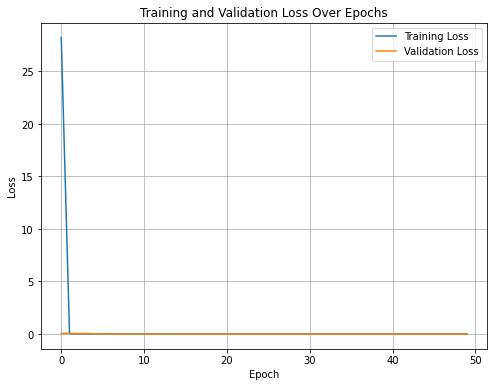

In [ ]:
# Plot training and validation loss curves
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Save the loss curve as an image
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')  # Save as PNG file
plt.close()


In [3]:
# Initialize total counts for overall accuracy calculation
total_correct = 0
total_points = 0

# For each sample in the test set
for data_path in test_paths:
    print(f"Processing: {data_path}")
    try:
        # Load and preprocess data
        input_image, data = load_and_preprocess_data(data_path, augment=False)
        height, width, _ = input_image.shape

        # Add batch dimension
        input_image_exp = np.expand_dims(input_image, axis=0)  # Shape becomes (1, H, W, C)
        
        # Make prediction
        prediction = model.predict(input_image_exp)
        if prediction.shape[-1] < 2:
            raise ValueError(f"Incorrect prediction output shape: {prediction.shape}")
        A_pred, B_pred = prediction[0]  # Prediction result shape is (1, 2)

        # Read original 'A' and 'B' values
        settings_json_path = os.path.join(data_path, 'settings.json')
        if not os.path.exists(settings_json_path):
            raise ValueError(f"File not found: {settings_json_path}")
        with open(settings_json_path, 'r') as f_json:
            json_data = json.load(f_json)

        # Extract 'boundaries'
        boundaries = json_data.get('boundaries', [])
        if len(boundaries) < 3:
            raise ValueError(f"'boundaries' values in JSON file {settings_json_path} are insufficient")
        # Get the second and third values as A and B
        A_orig, B_orig = boundaries[1:3]
        A_orig = float(A_orig)
        B_orig = float(B_orig)

        # Map to pixel coordinates
        F_values = data['F'].values

        # Compute class labels
        # For original
        class_labels_orig = []
        for F in F_values:
            if F < A_orig:
                class_labels_orig.append(1)  # class1 (yellow)
            elif F <= B_orig:
                class_labels_orig.append(2)  # class2 (red)
            else:
                class_labels_orig.append(3)  # class3 (blue)

        # For predicted
        class_labels_pred = []
        for F in F_values:
            if F < A_pred:
                class_labels_pred.append(1)  # class1 (yellow)
            elif F <= B_pred:
                class_labels_pred.append(2)  # class2 (red)
            else:
                class_labels_pred.append(3)  # class3 (blue)

        # Convert to numpy arrays
        class_labels_orig = np.array(class_labels_orig)
        class_labels_pred = np.array(class_labels_pred)

        # Compute overall accuracy for this sample
        sample_total_points = len(class_labels_orig)
        sample_correct_predictions = np.sum(class_labels_orig == class_labels_pred)
        sample_accuracy = sample_correct_predictions / sample_total_points

        # Update total counts for overall accuracy
        total_correct += sample_correct_predictions
        total_points += sample_total_points

        # Print accuracy for this sample
        print(f"Overall accuracy: {sample_accuracy:.2%} ({sample_correct_predictions}/{sample_total_points})")

    except Exception as e:
        print(f"Error processing {data_path}: {e}")

# Calculate total overall accuracy across all samples
if total_points > 0:
    overall_accuracy = total_correct / total_points
    print(f"\nTotal Overall Accuracy: {overall_accuracy:.2%} ({total_correct}/{total_points})")
else:
    print("\nNo data processed. Total accuracy cannot be computed.")


Processing: test_set/Random_series_011
1/1 [==============================] - 0s 21ms/step
Overall accuracy: 82.93% (6711/8092)
Processing: test_set/Random_series_013
1/1 [==============================] - 0s 24ms/step
Overall accuracy: 77.22% (6249/8092)
Processing: test_set/Random_series_019
1/1 [==============================] - 0s 27ms/step
Overall accuracy: 75.58% (6116/8092)
Processing: test_set/Random_series_020
1/1 [==============================] - 0s 26ms/step
Overall accuracy: 93.67% (7580/8092)
Processing: test_set/Random_series_037
1/1 [==============================] - 0s 23ms/step
Overall accuracy: 83.92% (6791/8092)
Processing: test_set/Random_series_055
1/1 [==============================] - 0s 24ms/step
Overall accuracy: 96.26% (7789/8092)
Processing: test_set/Random_series_062
1/1 [==============================] - 0s 24ms/step
Overall accuracy: 92.88% (7516/8092)
Processing: test_set/Random_series_070
1/1 [==============================] - 0s 20ms/step
Overall accur